# ***Crawl thông tin của sản phẩm UNIQLO***

## ***Phân tích để lấy ra giá tiền***

In [8]:
import re

def extract_price_vnd(text: str):

    match = re.search(r'\d{1,3}(?:\.\d{3})*\s*VND', text)
    return match.group() if match else None

text = "Trẻ em, 4-5Y(110)-14Y(160) HEATTECH Ultra Warm Áo Thun Giữ Nhiệt Cổ Tròn Sản phẩm được làm từ chất liệu tái chế 391.000 VND 4-5Y(110)-14Y(160) 4.9 (155)"

print(extract_price_vnd(text))

391.000 VND


## ***Chỉ lấy ra first-item (item được chọn trong trang web) là Heattech***

In [25]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
import pandas as pd
import time
import re


def extract_price_vnd(text):
    match = re.search(r'\d{1,3}(?:\.\d{3})*\s*VND', text)
    return match.group() if match else None


url = "https://www.uniqlo.com/vn/vi/special-feature/holiday-gift"

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

driver.get(url)
wait = WebDriverWait(driver, 20)
time.sleep(5)

heattech_block = wait.until(
    EC.presence_of_element_located(
        (By.CSS_SELECTOR, 'div.item-area.first-item[data-category="heattech"]')
    )
)

html = heattech_block.get_attribute("innerHTML")
driver.quit()

soup = BeautifulSoup(html, "html.parser")

products = []

product_cards = soup.find_all("a", href=True)

for card in product_cards:
    name_tag = card.find("p", class_="fr-bff-product_name")
    product_name = name_tag.get_text(strip=True) if name_tag else None

    raw_text = card.get_text(" ", strip=True)

    # -----------------------
    # Price
    # -----------------------
    price = extract_price_vnd(raw_text)

    # -----------------------
    # Gender / Size
    # -----------------------
    gender = ""
    size = ""

    name_tag = card.find(["h3", "p", "span"])
    gender_size_text = name_tag.get_text(strip=True) if name_tag else ""

    if gender_size_text.lower() == "unisex":
        gender = "Unisex"
        size = ""
    elif "," in gender_size_text:
        parts = gender_size_text.rsplit(",", 1)
        gender = parts[0].strip()
        size = parts[1].strip()
    else:
        gender = gender_size_text
        size = ""

    # -----------------------
    # Rate / Number of rates
    # -----------------------
    rate = ""
    number_of_rates = ""

    spans = [s.get_text(strip=True) for s in card.find_all("span")]
    rate_text = ",".join(spans)

    if "," in rate_text:
        parts = rate_text.rsplit(",", 1)
        number_of_rates = parts[1].strip()

        rate = ((parts[0].strip()).rsplit(",", 1))[1].strip()
    else:
        rate = ""
        number_of_rates = ""

    product = {
        "category": "heattech",
        "product_url": "https://www.uniqlo.com" + card["href"],
        "Product Name": product_name,
        "Gender": gender,
        "Size": size,
        "Price": price,
        "Rate": rate,
        "Number_of_rates": number_of_rates,
        "Description": raw_text
    }

    if price:
        products.append(product)

df = pd.DataFrame(products)
df.to_csv("uniqlo_heattech_products.csv", index=False, encoding="utf-8-sig")

print(f"✅ Đã crawl {len(df)} sản phẩm và lưu vào uniqlo_heattech_products.csv")

✅ Đã crawl 33 sản phẩm và lưu vào uniqlo_heattech_products.csv


## ***Giờ mới lấy hết các thứ có trong trang web này nè con trai***

In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

# Hàm trích xuất giá
def extract_price_vnd(text):
    match = re.search(r'\d{1,3}(?:\.\d{3})*\s*VND', text)
    return match.group() if match else None

url = "https://www.uniqlo.com/vn/vi/special-feature/holiday-gift"

# Cấu hình Chrome
options = webdriver.ChromeOptions()
# options.add_argument("--headless") # Bỏ comment nếu muốn chạy ẩn
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

driver.get(url)
wait = WebDriverWait(driver, 10)

# Cuộn trang từ từ để đảm bảo các phần tử được load (Lazy loading)
# Trang Uniqlo thường load nội dung khi cuộn xuống
last_height = driver.execute_script("return document.body.scrollHeight")
for i in range(3): 
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)

# Danh sách các danh mục cần lấy
target_categories = [
    "heattech", 
    "fleece", 
    "sweater_cardigan", 
    "accessories", 
    "outerwear", 
    "innerwear", 
    "loungewear", 
    "tshirts_polo", 
    "shirts", 
    "airism"
]

all_products = []

print("Bắt đầu crawl dữ liệu...")

for category in target_categories:
    try:
        print(f"--- Đang xử lý danh mục: {category} ---")
        
        # Tạo selector động dựa trên category
        # Lưu ý: Đã bỏ .first-item để tổng quát hơn, chỉ dựa vào data-category
        css_selector = f'div.item-area[data-category="{category}"]'
        
        # Chờ phần tử xuất hiện
        block_element = wait.until(
            EC.presence_of_element_located((By.CSS_SELECTOR, css_selector))
        )
        
        # Lấy HTML của block đó
        html = block_element.get_attribute("innerHTML")
        soup = BeautifulSoup(html, "html.parser")
        
        product_cards = soup.find_all("a", href=True)
        
        if not product_cards:
            print(f"   -> Không tìm thấy sản phẩm nào trong {category}")
            continue

        for card in product_cards:
            try:
                name_tag = card.find("p", class_="fr-bff-product_name")
                product_name = name_tag.get_text(strip=True) if name_tag else None

                raw_text = card.get_text(" ", strip=True)

                # -----------------------
                # Price
                # -----------------------
                price = extract_price_vnd(raw_text)

                # -----------------------
                # Gender / Size logic (Giữ nguyên logic của bạn)
                # -----------------------
                gender = ""
                size = ""

                # Tìm thẻ chứa thông tin giới tính/size (thường là h3 hoặc p đầu)
                # Logic này phụ thuộc nhiều vào cấu trúc HTML cụ thể
                info_tag = card.find(["h3", "p", "span"]) 
                gender_size_text = info_tag.get_text(strip=True) if info_tag else ""

                if gender_size_text.lower() == "unisex":
                    gender = "Unisex"
                    size = ""
                elif "," in gender_size_text:
                    parts = gender_size_text.rsplit(",", 1)
                    gender = parts[0].strip()
                    size = parts[1].strip()
                else:
                    gender = gender_size_text
                    size = ""

                # -----------------------
                # Rate / Number of rates logic (Giữ nguyên logic của bạn)
                # -----------------------
                rate = ""
                number_of_rates = ""

                spans = [s.get_text(strip=True) for s in card.find_all("span")]
                rate_text = ",".join(spans)

                # Logic tách chuỗi rate của bạn
                if "," in rate_text and len(parts) > 1:
                     # Cần cẩn thận logic này vì parts đang lấy từ gender phía trên nếu không reset
                     # Sửa lại logic tách rate an toàn hơn:
                     rate_parts = rate_text.rsplit(",", 1)
                     if len(rate_parts) > 1:
                        number_of_rates = rate_parts[1].strip()
                        # Cố gắng lấy rate, logic này hơi rủi ro nếu text khác format
                        sub_parts = rate_parts[0].strip().rsplit(",", 1)
                        if len(sub_parts) > 1:
                            rate = sub_parts[1].strip()
                        else:
                            rate = rate_parts[0].strip()
                
                # Chỉ thêm sản phẩm nếu có giá (theo logic gốc)
                if price:
                    product = {
                        "category": category, # Thêm cột category để phân biệt
                        "product_url": "https://www.uniqlo.com" + card["href"] if card["href"].startswith("/") else card["href"],
                        "Product Name": product_name,
                        "Gender": gender,
                        "Size": size,
                        "Price": price,
                        "Rate": rate,
                        "Number_of_rates": number_of_rates,
                        "Description": raw_text
                    }
                    all_products.append(product)
            except Exception as e:
                # Bỏ qua lỗi nhỏ trong từng card để không dừng luồng
                continue

    except Exception as e:
        print(f"Lỗi hoặc không tìm thấy danh mục '{category}': {e}")
        continue

driver.quit()

# Lưu dữ liệu
if all_products:
    df = pd.DataFrame(all_products)
    output_file = "uniqlo_holiday_products.csv"
    df.to_csv(output_file, index=False, encoding="utf-8-sig")
    print(f"✅ Đã crawl tổng cộng {len(df)} sản phẩm và lưu vào {output_file}")
else:
    print("❌ Không crawl được sản phẩm nào.")

Bắt đầu crawl dữ liệu...
--- Đang xử lý danh mục: heattech ---
--- Đang xử lý danh mục: fleece ---
--- Đang xử lý danh mục: sweater_cardigan ---
--- Đang xử lý danh mục: accessories ---
--- Đang xử lý danh mục: outerwear ---
--- Đang xử lý danh mục: innerwear ---
--- Đang xử lý danh mục: loungewear ---
--- Đang xử lý danh mục: tshirts_polo ---
--- Đang xử lý danh mục: shirts ---
--- Đang xử lý danh mục: airism ---
✅ Đã crawl tổng cộng 161 sản phẩm và lưu vào uniqlo_holiday_products.csv


## ***Dựa vào link lấy ra thêm thông tin về product code và washing guide lẫn material***

In [2]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

# =========================
# 1️⃣ ĐỌC FILE CSV
# =========================
input_csv = "uniqlo_holiday_products.csv"
df = pd.read_csv(input_csv)

# Đảm bảo cột product_url tồn tại
if "product_url" not in df.columns:
    raise ValueError("❌ File CSV phải có cột 'product_url'")

# =========================
# 2️⃣ KHỞI TẠO CỘT MỚI
# =========================
df["Chất liệu"] = ""
df["Hướng dẫn giặt"] = ""
df["Mã sản phẩm"] = ""

# =========================
# 3️⃣ CẤU HÌNH SELENIUM
# =========================
options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

# =========================
# 4️⃣ DUYỆT TỪNG PRODUCT URL
# =========================
for idx, row in df.iterrows():
    url = row["product_url"]

    print(f"🔍 Crawling {idx + 1}/{len(df)}: {url}")

    try:
        driver.get(url)
        time.sleep(3)

        soup = BeautifulSoup(driver.page_source, "html.parser")

        material = None
        wash_guide = None
        product_code = None

        sr_sections = soup.select("section.enable-sr-group")

        for section in sr_sections:
            lines = [
                l.strip()
                for l in section.get_text("\n").split("\n")
                if l.strip()
            ]

            for i, line in enumerate(lines):
                # Chất liệu
                if line == "Vải" and i + 1 < len(lines):
                    material = lines[i + 1]

                # Hướng dẫn giặt
                if line == "Hướng dẫn giặt" and i + 1 < len(lines):
                    wash_guide = lines[i + 1]

                # Mã sản phẩm
                if "Mã sản phẩm" in line:
                    match = re.search(
                        r"Mã sản phẩm\s*[:：]?\s*([A-Z0-9\-]+)", line
                    )
                    if match:
                        product_code = match.group(1)

        # Fallback mã sản phẩm từ URL
        if not product_code:
            match = re.search(r"/products/([A-Z0-9\-]+)", url)
            if match:
                product_code = match.group(1)

        # Ghi ngược vào DataFrame
        df.at[idx, "Chất liệu"] = material
        df.at[idx, "Hướng dẫn giặt"] = wash_guide
        df.at[idx, "Mã sản phẩm"] = product_code

    except Exception as e:
        print(f"⚠️ Lỗi tại {url}: {e}")

# =========================
# 5️⃣ ĐÓNG DRIVER
# =========================
driver.quit()

# =========================
# 6️⃣ GHI LẠI CSV (OVERWRITE)
# =========================
df.to_csv(
    input_csv,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Đã crawl xong toàn bộ sản phẩm và lưu vào file CSV")
df


🔍 Crawling 1/161: https://www.uniqlo.com/vn/vi/products/E481441-000?colorCode=COL30
🔍 Crawling 2/161: https://www.uniqlo.com/vn/vi/products/E478949-000?colorCode=COL01
🔍 Crawling 3/161: https://www.uniqlo.com/vn/vi/products/E442063-000?colorCode=COL32
🔍 Crawling 4/161: https://www.uniqlo.com/vn/vi/products/E479525-000?colorCode=COL69
🔍 Crawling 5/161: https://www.uniqlo.com/vn/vi/products/E478623-000?colorCode=COL70
🔍 Crawling 6/161: https://www.uniqlo.com/vn/vi/products/E478628-000?colorCode=COL01
🔍 Crawling 7/161: https://www.uniqlo.com/vn/vi/products/E478634-000?colorCode=COL09
🔍 Crawling 8/161: https://www.uniqlo.com/vn/vi/products/E478444-000?colorCode=COL09
🔍 Crawling 9/161: https://www.uniqlo.com/vn/vi/products/E478303-000?colorCode=COL01
🔍 Crawling 10/161: https://www.uniqlo.com/vn/vi/products/E481257-000?colorCode=COL05
🔍 Crawling 11/161: https://www.uniqlo.com/vn/vi/products/E478144-000?colorCode=COL10
🔍 Crawling 12/161: https://www.uniqlo.com/vn/vi/products/E478312-000?color

,category,product_url,Product Name,Gender,Size,Price,Rate,Number_of_rates,Description,Chất liệu,Hướng dẫn giặt,Mã sản phẩm
0,heattech,https://www.uniqlo.com/vn/vi/products/E481441-...,HEATTECH Extra Warm Áo Thun Len Cashmere Cổ Tròn,Nam,S-XL,489.000 VND,4.9,(110),"Nam, S-XL HEATTECH Extra Warm Áo Thun Len Cash...","57% Acrylic, 28% Visco, 9% Len Casomia, 6% Ela...","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",481441
1,heattech,https://www.uniqlo.com/vn/vi/products/E478949-...,HEATTECH Extra Warm Áo Thun Giữ Nhiệt Cổ Tròn,Nữ,XS-XXL,489.000 VND,4.9,(86),"Nữ, XS-XXL HEATTECH Extra Warm Áo Thun Giữ Nhi...","63% Bông, 29% Acrylic, 8% Elastan","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",478949
2,heattech,https://www.uniqlo.com/vn/vi/products/E442063-...,HEATTECH Áo Giữ Nhiệt Giả Lông Cừu | Cổ Lọ,Nữ,XS-XXL,391.000 VND,4.8,(966),"Nữ, XS-XXL HEATTECH Áo Giữ Nhiệt Giả Lông Cừu ...","70% Acrylic, 30% Visco","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",479608
3,heattech,https://www.uniqlo.com/vn/vi/products/E479525-...,HEATTECH Ultra Warm Áo Thun Giữ Nhiệt Cổ Tròn,Nam,XS-XXL,588.000 VND,4.9,(158),"Nam, XS-XXL HEATTECH Ultra Warm Áo Thun Giữ Nh...","35% Polyeste, 34% Acrylic, 23% Visco, 8% Elast...","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",479525
4,heattech,https://www.uniqlo.com/vn/vi/products/E478623-...,HEATTECH Áo Thun Giữ Nhiệt Cổ Rộng,Trẻ em,4-5Y(110)-14Y(160),244.000 VND,5.0,(14),"Trẻ em, 4-5Y(110)-14Y(160) HEATTECH Áo Thun Gi...","35% Acrylic, 30% Polyeste, 24% Visco, 11% Elas...","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",478623
...,...,...,...,...,...,...,...,...,...,...,...,...
156,airism,https://www.uniqlo.com/vn/vi/products/E474832-...,AIRism Áo Thun Vải Cotton,Trẻ em,4-5Y(110)-14Y(160),293.000 VND,4.9,(59),"Trẻ em, 4-5Y(110)-14Y(160) AIRism Áo Thun Vải ...","Thân: 53% Bông, 47% Polyeste ( 30% Sử Dụng Sợi...","Giặt máy nước lạnh, Không giặt khô, Không sấy khô",483438
157,airism,https://www.uniqlo.com/vn/vi/products/E483438-...,AIRism Cotton Áo Thun,Trẻ em,4-5Y(110)-14Y(160),293.000 VND,NaN,NaN,"Trẻ em, 4-5Y(110)-14Y(160) AIRism Cotton Áo Th...","Thân: 53% Bông, 47% Polyeste ( 30% Sử Dụng Sợi...","Giặt máy nước lạnh, Không giặt khô, Không sấy khô",483438
158,airism,https://www.uniqlo.com/vn/vi/products/E483440-...,AIRism Cotton Áo Thun In Họa Tiết,Trẻ em,4-5Y(110)-14Y(160),293.000 VND,5.0,(1),"Trẻ em, 4-5Y(110)-14Y(160) AIRism Cotton Áo Th...","Thân: 53% Bông, 47% Polyeste ( 30% Sử Dụng Sợi...","Giặt máy nước lạnh, Không giặt khô, Không sấy khô",483440
159,airism,https://www.uniqlo.com/vn/vi/products/E482984-...,AIRism Cotton Áo Thun In Họa Tiết,Trẻ em,4-5Y(110)-14Y(160),293.000 VND,4.7,(4),"Trẻ em, 4-5Y(110)-14Y(160) AIRism Cotton Áo Th...","Thân: 53% Bông, 47% Polyeste ( 30% Sử Dụng Sợi...","Giặt máy nước lạnh, Không giặt khô, Không sấy khô",483441


## ***Lấy link hình ảnh***

### ***Lảy ra link hình ảnh từ link***

In [14]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# 1. Cấu hình Driver
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36")
chrome_options.add_argument("--headless") # Chạy ẩn để nhanh hơn

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

try:
    # 2. Link sản phẩm bạn cung cấp
    url = "https://www.uniqlo.com/vn/vi/products/E475373-000?colorCode=COL69"
    print(f"Đang truy cập: {url}")
    driver.get(url)

    # 3. Chờ phần section chứa ảnh load xong (Dựa vào data-section="product-image" trong hình bạn gửi)
    wait = WebDriverWait(driver, 10)
    
    # XPath này đi vào section có data-section='product-image', sau đó tìm thẻ img đầu tiên bên trong nó
    image_xpath = "//section[@data-section='product-image']//img"
    
    # Chờ ảnh xuất hiện
    image_element = wait.until(EC.presence_of_element_located((By.XPATH, image_xpath)))
    
    # 4. Lấy link ảnh (thuộc tính src)
    image_link = image_element.get_attribute("src")
    
    print("-" * 30)
    print("LINK HÌNH ẢNH TÌM THẤY:")
    print(image_link)
    print("-" * 30)

except Exception as e:
    print(f"Lỗi: {e}")

finally:
    driver.quit()

Đang truy cập: https://www.uniqlo.com/vn/vi/products/E475373-000?colorCode=COL69
------------------------------
LINK HÌNH ẢNH TÌM THẤY:
https://image.uniqlo.com/UQ/ST3/vn/imagesgoods/475373/item/vngoods_69_475373_3x4.jpg?width=369
------------------------------


## ***Giờ mới lấy thật nè con trai***

In [16]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# --- 1. CẤU HÌNH DRIVER ---
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36")
# chrome_options.add_argument("--headless") # Bỏ comment dòng này nếu muốn chạy ẩn (nhanh hơn)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
driver.maximize_window() # Mở rộng để đảm bảo load đủ element
wait = WebDriverWait(driver, 10)

# --- 2. ĐỌC FILE CSV ---
input_filename = 'uniqlo_holiday_products.csv'
try:
    df = pd.read_csv(input_filename)
    print(f"Đã đọc file {input_filename} với {len(df)} dòng.")
except FileNotFoundError:
    print("Không tìm thấy file csv. Vui lòng kiểm tra lại tên file.")
    driver.quit()
    exit()

# Tạo list để chứa các link ảnh tìm được
img_urls_list = []

# --- 3. DUYỆT QUA TỪNG URL ---
for index, row in df.iterrows():
    product_url = row.get('product_url')
    
    # Kiểm tra url hợp lệ
    if pd.isna(product_url) or not str(product_url).startswith('http'):
        print(f"[{index+1}] URL không hợp lệ, bỏ qua.")
        img_urls_list.append("N/A")
        continue

    print(f"[{index+1}/{len(df)}] Đang lấy ảnh: {product_url}")

    try:
        driver.get(product_url)
        
        # XPath dựa trên hình inspect bạn gửi: 
        # Tìm thẻ section có data-section='product-image', sau đó lấy thẻ img bên trong
        image_xpath = "//section[@data-section='product-image']//img"
        
        # Chờ ảnh xuất hiện
        img_element = wait.until(EC.presence_of_element_located((By.XPATH, image_xpath)))
        
        # Lấy thuộc tính src
        img_src = img_element.get_attribute("src")
        print(f"   -> Link ảnh: {img_src[:50]}...") # In rút gọn cho đỡ rối
        
        img_urls_list.append(img_src)

    except Exception as e:
        print(f"   -> Không lấy được ảnh (Lỗi: {e})")
        img_urls_list.append("N/A") # Nếu lỗi thì điền N/A

# --- 4. CẬP NHẬT VÀ LƯU FILE ---
driver.quit()

# Thêm cột mới vào DataFrame
df['img_url'] = img_urls_list

# Lưu ra file mới (khuyên dùng cách này để tránh lỗi file gốc khi đang mở)
df.to_csv(input_filename, index=False, encoding='utf-8-sig')

print(f"Hoàn thành! File đã được lưu tại: {input_filename}")
df

Đã đọc file uniqlo_holiday_products.csv với 161 dòng.
[1/161] Đang lấy ảnh: https://www.uniqlo.com/vn/vi/products/E481441-000?colorCode=COL30
   -> Link ảnh: https://image.uniqlo.com/UQ/ST3/vn/imagesgoods/481...
[2/161] Đang lấy ảnh: https://www.uniqlo.com/vn/vi/products/E478949-000?colorCode=COL01
   -> Link ảnh: https://image.uniqlo.com/UQ/ST3/vn/imagesgoods/478...
[3/161] Đang lấy ảnh: https://www.uniqlo.com/vn/vi/products/E442063-000?colorCode=COL32
   -> Link ảnh: https://image.uniqlo.com/UQ/ST3/vn/imagesgoods/442...
[4/161] Đang lấy ảnh: https://www.uniqlo.com/vn/vi/products/E479525-000?colorCode=COL69
   -> Link ảnh: https://image.uniqlo.com/UQ/ST3/vn/imagesgoods/479...
[5/161] Đang lấy ảnh: https://www.uniqlo.com/vn/vi/products/E478623-000?colorCode=COL70
   -> Link ảnh: https://image.uniqlo.com/UQ/ST3/AsianCommon/images...
[6/161] Đang lấy ảnh: https://www.uniqlo.com/vn/vi/products/E478628-000?colorCode=COL01
   -> Link ảnh: https://image.uniqlo.com/UQ/ST3/AsianCommon/images..

,category,product_url,Product Name,Gender,Size,Price,Rate,Number_of_rates,Description,Chất liệu,Hướng dẫn giặt,Mã sản phẩm,img_url
0,heattech,https://www.uniqlo.com/vn/vi/products/E481441-...,HEATTECH Extra Warm Áo Thun Len Cashmere Cổ Tròn,Nam,S-XL,489.000 VND,4.9,(110),"Nam, S-XL HEATTECH Extra Warm Áo Thun Len Cash...","57% Acrylic, 28% Visco, 9% Len Casomia, 6% Ela...","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",481441,https://image.uniqlo.com/UQ/ST3/vn/imagesgoods...
1,heattech,https://www.uniqlo.com/vn/vi/products/E478949-...,HEATTECH Extra Warm Áo Thun Giữ Nhiệt Cổ Tròn,Nữ,XS-XXL,489.000 VND,4.9,(86),"Nữ, XS-XXL HEATTECH Extra Warm Áo Thun Giữ Nhi...","63% Bông, 29% Acrylic, 8% Elastan","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",478949,https://image.uniqlo.com/UQ/ST3/vn/imagesgoods...
2,heattech,https://www.uniqlo.com/vn/vi/products/E442063-...,HEATTECH Áo Giữ Nhiệt Giả Lông Cừu | Cổ Lọ,Nữ,XS-XXL,391.000 VND,4.8,(966),"Nữ, XS-XXL HEATTECH Áo Giữ Nhiệt Giả Lông Cừu ...","70% Acrylic, 30% Visco","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",479608,https://image.uniqlo.com/UQ/ST3/vn/imagesgoods...
3,heattech,https://www.uniqlo.com/vn/vi/products/E479525-...,HEATTECH Ultra Warm Áo Thun Giữ Nhiệt Cổ Tròn,Nam,XS-XXL,588.000 VND,4.9,(158),"Nam, XS-XXL HEATTECH Ultra Warm Áo Thun Giữ Nh...","35% Polyeste, 34% Acrylic, 23% Visco, 8% Elast...","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",479525,https://image.uniqlo.com/UQ/ST3/vn/imagesgoods...
4,heattech,https://www.uniqlo.com/vn/vi/products/E478623-...,HEATTECH Áo Thun Giữ Nhiệt Cổ Rộng,Trẻ em,4-5Y(110)-14Y(160),244.000 VND,5.0,(14),"Trẻ em, 4-5Y(110)-14Y(160) HEATTECH Áo Thun Gi...","35% Acrylic, 30% Polyeste, 24% Visco, 11% Elas...","Giặt máy nước lạnh, giặt nhẹ, Không giặt khô, ...",478623,https://image.uniqlo.com/UQ/ST3/AsianCommon/im...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,airism,https://www.uniqlo.com/vn/vi/products/E474832-...,AIRism Áo Thun Vải Cotton,Trẻ em,4-5Y(110)-14Y(160),293.000 VND,4.9,(59),"Trẻ em, 4-5Y(110)-14Y(160) AIRism Áo Thun Vải ...","Thân: 53% Bông, 47% Polyeste ( 30% Sử Dụng Sợi...","Giặt máy nước lạnh, Không giặt khô, Không sấy khô",483438,https://image.uniqlo.com/UQ/ST3/vn/imagesgoods...
157,airism,https://www.uniqlo.com/vn/vi/products/E483438-...,AIRism Cotton Áo Thun,Trẻ em,4-5Y(110)-14Y(160),293.000 VND,NaN,NaN,"Trẻ em, 4-5Y(110)-14Y(160) AIRism Cotton Áo Th...","Thân: 53% Bông, 47% Polyeste ( 30% Sử Dụng Sợi...","Giặt máy nước lạnh, Không giặt khô, Không sấy khô",483438,https://image.uniqlo.com/UQ/ST3/vn/imagesgoods...
158,airism,https://www.uniqlo.com/vn/vi/products/E483440-...,AIRism Cotton Áo Thun In Họa Tiết,Trẻ em,4-5Y(110)-14Y(160),293.000 VND,5.0,(1),"Trẻ em, 4-5Y(110)-14Y(160) AIRism Cotton Áo Th...","Thân: 53% Bông, 47% Polyeste ( 30% Sử Dụng Sợi...","Giặt máy nước lạnh, Không giặt khô, Không sấy khô",483440,https://image.uniqlo.com/UQ/ST3/vn/imagesgoods...
159,airism,https://www.uniqlo.com/vn/vi/products/E482984-...,AIRism Cotton Áo Thun In Họa Tiết,Trẻ em,4-5Y(110)-14Y(160),293.000 VND,4.7,(4),"Trẻ em, 4-5Y(110)-14Y(160) AIRism Cotton Áo Th...","Thân: 53% Bông, 47% Polyeste ( 30% Sử Dụng Sợi...","Giặt máy nước lạnh, Không giặt khô, Không sấy khô",483441,https://image.uniqlo.com/UQ/ST3/vn/imagesgoods...


## ***Đọc hình ảnh***

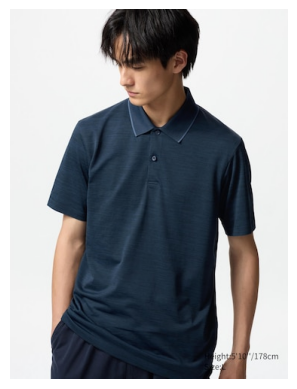

Kích thước ảnh: (369, 492)
Định dạng ảnh: JPEG


In [20]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

url = "https://image.uniqlo.com/UQ/ST3/vn/imagesgoods/475373/item/vngoods_69_475373_3x4.jpg?width=369"

# Tải ảnh từ URL
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Hiển thị ảnh
plt.imshow(img)
plt.axis('off') # Tắt trục tọa độ cho đẹp
plt.show()

print(f"Kích thước ảnh: {img.size}")
print(f"Định dạng ảnh: {img.format}")



# ***Lấy ra user***

## ***Lấy ra thử***

**Với link product_url trong phần product thì chỉ có thể lấy được những comment hiện hữu thôi, vậy nên phải có thao tác chuyển từ link product_url sang link review**

Ví dụ: link product là https://www.uniqlo.com/vn/vi/products/E481441-000?colorCode=COL30&sizeCode=SMA004 thì sẽ chuyển phần đuôi thành reviews như vầy https://www.uniqlo.com/vn/vi/products/E481441-000/reviews (chuyển phần "?colorCode=COL30&sizeCode=SMA004" thành "/reviews")

In [16]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# 1. Cấu hình Chrome Driver
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

all_data = []

try:
    # 2. Truy cập link
    url = "https://www.uniqlo.com/vn/vi/products/E481441-000/reviews"
    print(f"Đang truy cập: {url}")
    driver.get(url)

    # 3. Chờ load container
    wait = WebDriverWait(driver, 15)
    wait.until(EC.presence_of_element_located((By.ID, "allReviews-container")))
    
    driver.execute_script("window.scrollBy(0, 600);")
    time.sleep(3)

    # 4. Tìm các thẻ review
    review_cards = driver.find_elements(By.XPATH, "//div[contains(@class, 'fr-ec-review__header')]/parent::div")
    print(f"-> Tìm thấy {len(review_cards)} reviews.")

    # 5. Duyệt và tách dữ liệu
    for card in review_cards:
        reviewer_name = gender = age_range = height = weight = shoe_size = country = None
        header_comment = ""
        review_date = None
        rating = None  # Khởi tạo biến rating

        # --- XỬ LÝ RATING (YÊU CẦU MỚI) ---
        try:
            # Tìm class fr-implicit bên trong card
            rating_el = card.find_element(By.CLASS_NAME, "fr-implicit")
            # Sử dụng textContent vì class này thường chứa text ẩn cho screen reader
            rating = rating_el.get_attribute("textContent").strip()
        except:
            rating = "N/A"

        # --- XỬ LÝ HEADER (Tách Comment và Date) ---
        try:
            full_header = card.find_element(By.CLASS_NAME, "fr-ec-review__header").text.strip()
            if "\n" in full_header:
                header_parts = full_header.split("\n")
                header_comment = header_parts[0].strip()
                review_date = header_parts[-1].strip()
            else:
                header_comment = full_header
        except: 
            pass

        # --- XỬ LÝ INFO ---
        try:
            info_el = card.find_element(By.CLASS_NAME, "fr-ec-review__info")
            raw_info = info_el.text.strip()
            parts = raw_info.split(" · ")
            
            for i, part in enumerate(parts):
                part = part.strip()
                if i == 0: reviewer_name = part
                elif part in ["Nam", "Nữ"]: gender = part
                elif "tuổi" in part: age_range = part
                elif "Chiều cao" in part: height = part.replace("Chiều cao:", "").strip()
                elif "Cân nặng" in part: weight = part.replace("Cân nặng:", "").strip()
                elif "Cỡ giày" in part: shoe_size = part.replace("Cỡ giày:", "").strip()
                elif ":" not in part: country = part
        except:
            pass

        # Thêm vào list data
        all_data.append({
            "Reviewer": reviewer_name,
            "Rating": rating,              # Thêm cột Rating
            "Comment": header_comment,
            "Review Date": review_date,
            "Gender": gender,
            "Age": age_range,
            "Height": height,
            "Weight": weight,
            "Shoe Size": shoe_size,
            "Country": country
        })

except Exception as e:
    print(f"Lỗi chung: {e}")

finally:
    driver.quit()

# 6. Xuất ra DataFrame
df = pd.DataFrame(all_data)
df

Đang truy cập: https://www.uniqlo.com/vn/vi/products/E481441-000/reviews
-> Tìm thấy 5 reviews.


,Reviewer,Rating,Comment,Review Date,Gender,Age,Height,Weight,Shoe Size,Country
0,Nina,5 out of 5 stars,Stylish and warm,17/12/2025,Nam,35 đến 44 tuổi,176 - 180cm,66 - 70kg,EU41,Singapore
1,Jelly,5 out of 5 stars,Heattech vô địch,17/12/2025,Nam,65 tuổi và hơn,166 - 170cm,66 - 70kg,None,Hà Tĩnh
2,Paul,5 out of 5 stars,Great product,16/12/2025,Nam,65 tuổi và hơn,181 - 185cm,91kg trở lên,EU47,Kuala Lumpur
3,Edmund,5 out of 5 stars,Light and comfortable,16/12/2025,Nam,55 đến 64 tuổi,171 - 175cm,76 - 80kg,EU43,Singapore
4,Chew,5 out of 5 stars,Thin and comfortable material,15/12/2025,Nam,None,166 - 170cm,None,None,Singapore


## ***Bấm vào nút Tải thêm***
**Demo bấm thử**

In [ ]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# 1. Cấu hình Chrome Driver
chrome_options = Options()
# Thêm argument để tránh bị phát hiện bot và chạy ổn định hơn
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36")
chrome_options.add_argument("--disable-notifications")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
driver.maximize_window() # Mở rộng màn hình để dễ scroll

all_data = []

try:
    # 2. Truy cập link
    url = "https://www.uniqlo.com/vn/vi/products/E481441-000/reviews"
    print(f"Đang truy cập: {url}")
    driver.get(url)

    wait = WebDriverWait(driver, 15)
    
    # Chờ container review chính xuất hiện
    wait.until(EC.presence_of_element_located((By.ID, "allReviews-container")))
    time.sleep(2)

    # --- PHẦN MỚI: XỬ LÝ NÚT "TẢI THÊM" ---
    so_lan_bam = 2  # Bạn muốn bấm 2 lần
    
    for i in range(so_lan_bam):
        try:
            # Tìm nút dựa trên cấu trúc trong ảnh bạn gửi: div[data-test="view-more-button"] -> a
            # Dùng XPath để tìm chính xác thẻ <a> bên trong div có data-test kia
            load_more_xpath = "//div[@data-test='view-more-button']//a"
            
            # Chờ nút xuất hiện
            load_more_btn = wait.until(EC.presence_of_element_located((By.XPATH, load_more_xpath)))
            
            # Scroll tới nút đó để đảm bảo nó nằm trong vùng nhìn thấy
            driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", load_more_btn)
            time.sleep(1) # Nghỉ xíu sau khi scroll
            
            # Click bằng Javascript (An toàn hơn click() thường vì tránh bị banner che)
            driver.execute_script("arguments[0].click();", load_more_btn)
            
            print(f"-> Đã bấm 'Tải thêm' lần {i+1}")
            
            # Chờ dữ liệu mới load ra (quan trọng)
            time.sleep(3) 
            
        except Exception as e:
            print(f"-> Không bấm được nút tải thêm ở lần {i+1} (Có thể đã hết review).")
            break
    # ---------------------------------------

    # 4. Tìm các thẻ review (Sau khi đã load đủ)
    # Scroll lại lên một chút hoặc giữ nguyên cũng được, code find_elements sẽ tìm trong toàn bộ DOM
    review_cards = driver.find_elements(By.XPATH, "//div[contains(@class, 'fr-ec-review__header')]/parent::div")
    print(f"-> Tổng tìm thấy {len(review_cards)} reviews sau khi load thêm.")

    # 5. Duyệt và tách dữ liệu (Code cũ của bạn giữ nguyên)
    for card in review_cards:
        reviewer_name = gender = age_range = height = weight = shoe_size = country = None
        header_comment = ""
        review_date = None
        rating = "N/A"

        # --- XỬ LÝ RATING ---
        try:
            rating_el = card.find_element(By.CLASS_NAME, "fr-implicit")
            rating = rating_el.get_attribute("textContent").strip()
        except:
            pass

        # --- XỬ LÝ HEADER ---
        try:
            full_header = card.find_element(By.CLASS_NAME, "fr-ec-review__header").text.strip()
            if "\n" in full_header:
                header_parts = full_header.split("\n")
                header_comment = header_parts[0].strip()
                review_date = header_parts[-1].strip()
            else:
                header_comment = full_header
        except: 
            pass

        # --- XỬ LÝ INFO ---
        try:
            info_el = card.find_element(By.CLASS_NAME, "fr-ec-review__info")
            raw_info = info_el.text.strip()
            parts = raw_info.split(" · ") # Lưu ý ký tự đặc biệt này
            
            for i, part in enumerate(parts):
                part = part.strip()
                if i == 0: reviewer_name = part
                elif part in ["Nam", "Nữ"]: gender = part
                elif "tuổi" in part: age_range = part
                elif "Chiều cao" in part: height = part.replace("Chiều cao:", "").strip()
                elif "Cân nặng" in part: weight = part.replace("Cân nặng:", "").strip()
                elif "Cỡ giày" in part: shoe_size = part.replace("Cỡ giày:", "").strip()
                elif ":" not in part and part != "": country = part
        except:
            pass

        all_data.append({
            "Reviewer": reviewer_name,
            "Rating": rating,
            "Comment": header_comment,
            "Review Date": review_date,
            "Gender": gender,
            "Age": age_range,
            "Height": height,
            "Weight": weight,
            "Shoe Size": shoe_size,
            "Country": country
        })

except Exception as e:
    print(f"Lỗi chung: {e}")

finally:
    driver.quit()

# 6. Xuất ra DataFrame
df = pd.DataFrame(all_data)
df

Đang truy cập: https://www.uniqlo.com/vn/vi/products/E481441-000/reviews
-> Đã bấm 'Tải thêm' lần 1
-> Đã bấm 'Tải thêm' lần 2
-> Tổng tìm thấy 15 reviews sau khi load thêm.


,Reviewer,Rating,Comment,Review Date,Gender,Age,Height,Weight,Shoe Size,Country
0,Nina,5 out of 5 stars,Stylish and warm,17/12/2025,Nam,35 đến 44 tuổi,176 - 180cm,66 - 70kg,EU41,Singapore
1,Jelly,5 out of 5 stars,Heattech vô địch,17/12/2025,Nam,65 tuổi và hơn,166 - 170cm,66 - 70kg,None,Hà Tĩnh
2,Paul,5 out of 5 stars,Great product,16/12/2025,Nam,65 tuổi và hơn,181 - 185cm,91kg trở lên,EU47,Kuala Lumpur
3,Edmund,5 out of 5 stars,Light and comfortable,16/12/2025,Nam,55 đến 64 tuổi,171 - 175cm,76 - 80kg,EU43,Singapore
4,Chew,5 out of 5 stars,Thin and comfortable material,15/12/2025,Nam,None,166 - 170cm,None,None,Singapore
5,Sherly,5 out of 5 stars,Comfy and Trendy style,15/12/2025,Nữ,35 đến 44 tuổi,156 - 160cm,46 - 50kg,EU37,Singapore
6,Grace,5 out of 5 stars,Cashmere,15/12/2025,Nam,15 đến 19 tuổi,171 - 175cm,66 - 70kg,EU48,Selangor
7,Mochipeanut,5 out of 5 stars,Keep u warm in winter,14/12/2025,Nam,45 đến 54 tuổi,161 - 165cm,91kg trở lên,None,Singapore
8,Shun,4 out of 5 stars,No regrets,13/12/2025,Nam,None,None,None,None,Singapore
9,Goldfish,5 out of 5 stars,Effective to combat the cold weather overseas!,13/12/2025,Nam,None,None,None,None,Singapore


## ***Giờ mới lấy user thật nè con trai***

In [5]:
import time
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# --- 1. CẤU HÌNH & KHỞI TẠO DRIVER (Chỉ làm 1 lần) ---
chrome_options = Options()
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36")
chrome_options.add_argument("--disable-notifications") # Tắt thông báo
# chrome_options.add_argument("--headless") # Bỏ comment dòng này nếu muốn chạy ẩn (không hiện trình duyệt)

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
driver.maximize_window()
wait = WebDriverWait(driver, 10) # Thời gian chờ tối đa 10s cho mỗi element

all_reviews_data = []

# --- 2. ĐỌC FILE CSV ĐẦU VÀO ---
try:
    # Đọc file csv chứa danh sách sản phẩm
    input_df = pd.read_csv('uniqlo_holiday_products.csv')
    print(f"Đã đọc được {len(input_df)} sản phẩm từ file CSV.")
except Exception as e:
    print(f"Lỗi không đọc được file CSV: {e}")
    input_df = pd.DataFrame() # Tạo df rỗng để tránh lỗi code phía dưới

# --- 3. DUYỆT QUA TỪNG SẢN PHẨM ---
for index, row in input_df.iterrows():
    original_url = row.get('product_url', '')
    product_name = row.get('Product Name', 'N/A')
    product_code = row.get('Mã sản phẩm', 'N/A')

    # Bỏ qua nếu không có URL
    if not original_url or not isinstance(original_url, str):
        continue

    # --- XỬ LÝ URL ---
    # Cắt bỏ phần sau dấu ? và thêm /reviews
    # Ví dụ: .../products/E481441-000?colorCode=COL30 -> .../products/E481441-000/reviews
    clean_url = original_url.split('?')[0]
    review_url = f"{clean_url}/reviews"

    print(f"[{index+1}/{len(input_df)}] Đang cào: {product_name} - {product_code}")
    
    try:
        driver.get(review_url)
        
        # Kiểm tra xem có container review không (Nếu sản phẩm chưa có review nào thì sẽ lỗi ở đây hoặc timeout)
        try:
            wait.until(EC.presence_of_element_located((By.ID, "allReviews-container")))
        except:
            print(f"   -> Không tìm thấy khu vực review (Có thể sản phẩm chưa có đánh giá). Bỏ qua.")
            continue

        # --- CLICK "TẢI THÊM" (GIỮ NGUYÊN CODE CŨ) ---
        so_lan_bam = 10
        for i in range(so_lan_bam):
            try:
                load_more_xpath = "//div[@data-test='view-more-button']//a"
                load_more_btn = wait.until(EC.presence_of_element_located((By.XPATH, load_more_xpath)))
                driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", load_more_btn)
                time.sleep(1)
                driver.execute_script("arguments[0].click();", load_more_btn)
                print(f"   -> Đã bấm tải thêm lần {i+1}")
                time.sleep(2) # Chờ load
            except:
                break # Hết nút bấm hoặc lỗi thì thoát vòng lặp bấm
        
        # --- TÌM & TÁCH DỮ LIỆU ---
        review_cards = driver.find_elements(By.XPATH, "//div[contains(@class, 'fr-ec-review__header')]/parent::div")
        print(f"   -> Tìm thấy {len(review_cards)} reviews.")

        for card in review_cards:
            reviewer_name = gender = age_range = height = weight = shoe_size = country = None
            header_comment = ""
            review_date = None
            rating = "N/A"

            # Rating
            try:
                rating = card.find_element(By.CLASS_NAME, "fr-implicit").get_attribute("textContent").strip()
            except: pass

            # Header (Comment & Date)
            try:
                full_header = card.find_element(By.CLASS_NAME, "fr-ec-review__header").text.strip()
                if "\n" in full_header:
                    parts = full_header.split("\n")
                    header_comment = parts[0].strip()
                    review_date = parts[-1].strip()
                else:
                    header_comment = full_header
            except: pass

            # Info Attributes
            try:
                info_text = card.find_element(By.CLASS_NAME, "fr-ec-review__info").text.strip()
                info_parts = info_text.split(" · ")
                for idx, p in enumerate(info_parts):
                    p = p.strip()
                    if idx == 0: reviewer_name = p
                    elif p in ["Nam", "Nữ"]: gender = p
                    elif "tuổi" in p: age_range = p
                    elif "Chiều cao" in p: height = p.replace("Chiều cao:", "").strip()
                    elif "Cân nặng" in p: weight = p.replace("Cân nặng:", "").strip()
                    elif "Cỡ giày" in p: shoe_size = p.replace("Cỡ giày:", "").strip()
                    elif ":" not in p and p: country = p
            except: pass

            # --- LƯU DATA VÀO LIST (KÈM THÔNG TIN SẢN PHẨM) ---
            all_reviews_data.append({
                "product_url": original_url,        # URL gốc từ file input
                "Product Name": product_name,       # Tên SP từ file input
                "Mã sản phẩm": product_code,        # Mã SP từ file input
                "Reviewer": reviewer_name,
                "Rating": rating,
                "Comment": header_comment,
                "Review Date": review_date,
                "Gender": gender,
                "Age": age_range,
                "Height": height,
                "Weight": weight,
                "Shoe Size": shoe_size,
                "Country": country
            })

    except Exception as e:
        print(f"   -> Lỗi khi cào sản phẩm này: {e}")
        continue # Gặp lỗi ở sản phẩm này thì nhảy sang sản phẩm kế tiếp

driver.quit()

# --- 4. XUẤT RA FILE KẾT QUẢ ---
output_df = pd.DataFrame(all_reviews_data)
output_filename = 'uniqlo_reviews.csv'
output_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"\nĐã hoàn thành! Kết quả lưu tại file: {output_filename}")
print(output_df.head())

Đã đọc được 161 sản phẩm từ file CSV.
[1/161] Đang cào: HEATTECH Extra Warm Áo Thun Len Cashmere Cổ Tròn - 481441
   -> Đã bấm tải thêm lần 1
   -> Đã bấm tải thêm lần 2
   -> Đã bấm tải thêm lần 3
   -> Đã bấm tải thêm lần 4
   -> Đã bấm tải thêm lần 5
   -> Đã bấm tải thêm lần 6
   -> Đã bấm tải thêm lần 7
   -> Đã bấm tải thêm lần 8
   -> Đã bấm tải thêm lần 9
   -> Đã bấm tải thêm lần 10
   -> Tìm thấy 55 reviews.
[2/161] Đang cào: HEATTECH Extra Warm Áo Thun Giữ Nhiệt Cổ Tròn - 478949
   -> Đã bấm tải thêm lần 1
   -> Đã bấm tải thêm lần 2
   -> Đã bấm tải thêm lần 3
   -> Đã bấm tải thêm lần 4
   -> Đã bấm tải thêm lần 5
   -> Đã bấm tải thêm lần 6
   -> Đã bấm tải thêm lần 7
   -> Đã bấm tải thêm lần 8
   -> Đã bấm tải thêm lần 9
   -> Đã bấm tải thêm lần 10
   -> Tìm thấy 55 reviews.
[3/161] Đang cào: HEATTECH Áo Giữ Nhiệt Giả Lông Cừu | Cổ Lọ - 479608
   -> Đã bấm tải thêm lần 1
   -> Đã bấm tải thêm lần 2
   -> Đã bấm tải thêm lần 3
   -> Đã bấm tải thêm lần 4
   -> Đã bấm tả